<a href="https://colab.research.google.com/github/NadiaTeta/group1/blob/main/notebooks/03_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers

import torch
from transformers import GPT2LMHeadModel, GPT2TokenizerFast

torch.manual_seed(42)   # so random results are the same for everyone
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# load the already-trained GPT-2 (small version) from Hugging Face
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained(
    "gpt2",
    output_attentions=True,         # lets us look at attention weights
    output_hidden_states=True,      # lets us look at the numbers after each layer
    attn_implementation="eager",    # needed so attention weights can be returned
).to(device)
model.eval()                        # we're exploring, not training

print("Device:", device)
print(f"GPT-2 loaded: {sum(p.numel() for p in model.parameters()) / 1e6:.0f} million parameters")

# shared example sentences: the same meaning in English and Kinyarwanda
english = "The people of Kicukiro say they have not had water for three days."
kinyarwanda = "Abaturage bo mu Kicukiro bavuga ko bamaze iminsi itatu nta mazi bafite."

for name, sentence in [("English", english), ("Kinyarwanda", kinyarwanda)]:
    tokens = tokenizer.tokenize(sentence)
    print(f"\n{name}: {len(tokens)} tokens")
    print(tokens)




tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

[transformers] The following generation flags are not valid and may be ignored: ['output_attentions', 'output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Device: cpu
GPT-2 loaded: 124 million parameters

English: 17 tokens
['The', 'Ġpeople', 'Ġof', 'ĠK', 'ic', 'uk', 'iro', 'Ġsay', 'Ġthey', 'Ġhave', 'Ġnot', 'Ġhad', 'Ġwater', 'Ġfor', 'Ġthree', 'Ġdays', '.']

Kinyarwanda: 29 tokens
['Ab', 'atur', 'age', 'Ġbo', 'Ġmu', 'ĠK', 'ic', 'uk', 'iro', 'Ġb', 'av', 'uga', 'Ġko', 'Ġb', 'am', 'aze', 'Ġim', 'ins', 'i', 'Ġit', 'atu', 'Ġn', 'ta', 'Ġm', 'azi', 'Ġb', 'af', 'ite', '.']


### Visualizing GPT-2 Attention Patterns
We will pass the English sentence through GPT-2 to extract its attention weights, search for heads that exhibit clear structural behaviors (e.g., attending to the immediate previous token), and visualize them using heatmaps.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Encode the English sentence
inputs = tokenizer(english, return_tensors="pt").to(device)
input_tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# Run the model to get outputs, including attention weights
with torch.no_grad():
    outputs = model(**inputs)

# Attention weights shape: (num_layers, batch_size, num_heads, sequence_length, sequence_length)
attentions = outputs.attentions
num_layers = len(attentions)
num_heads = attentions[0].shape[1]  # Correct dimension for number of heads (batch_size, num_heads, seq_len, seq_len)

print(f"Retrieved attention weights for {num_layers} layers and {num_heads} heads.")
print(f"Sequence length: {len(input_tokens)} tokens.")

Retrieved attention weights for 12 layers and 12 heads.
Sequence length: 17 tokens.


Let's analyze the attention matrices to find heads that consistently attend to the previous token. A previous-token attention head will have high attention values along the sub-diagonal (i.e., position $i$ attending to position $i-1$).

In [8]:
prev_token_scores = []
seq_len = len(input_tokens)

# Safely query num_heads dynamically based on the shape of our model's attention matrix
current_num_heads = attentions[0].shape[1]

for layer in range(num_layers):
    # Extract attention for this layer: shape (num_heads, seq_len, seq_len)
    layer_attn = attentions[layer][0].cpu().numpy()
    for head in range(current_num_heads):
        matrix = layer_attn[head]
        # Calculate mean weight on the immediate sub-diagonal (excluding the first token which has no previous token)
        sub_diagonal_vals = [matrix[i, i-1] for i in range(1, seq_len)]
        mean_prev_attn = np.mean(sub_diagonal_vals)
        prev_token_scores.append((mean_prev_attn, layer, head))

# Sort to find the heads that most strongly attend to the previous token
prev_token_scores.sort(reverse=True, key=lambda x: x[0])

print("Top heads exhibiting 'Previous-Token' attention patterns:")
for score, layer, head in prev_token_scores[:3]:
    print(f"Layer {layer}, Head {head} | Mean sub-diagonal attention: {score:.4f}")

Top heads exhibiting 'Previous-Token' attention patterns:
Layer 4, Head 11 | Mean sub-diagonal attention: 0.9998
Layer 2, Head 2 | Mean sub-diagonal attention: 0.5500
Layer 3, Head 3 | Mean sub-diagonal attention: 0.4208


Now, we will visualize two interesting heads using heatmaps: one displaying a clear previous-token attention pattern, and another representing a different style of attention (such as attending heavily to the first token/delimiter or broad contextual distribution).

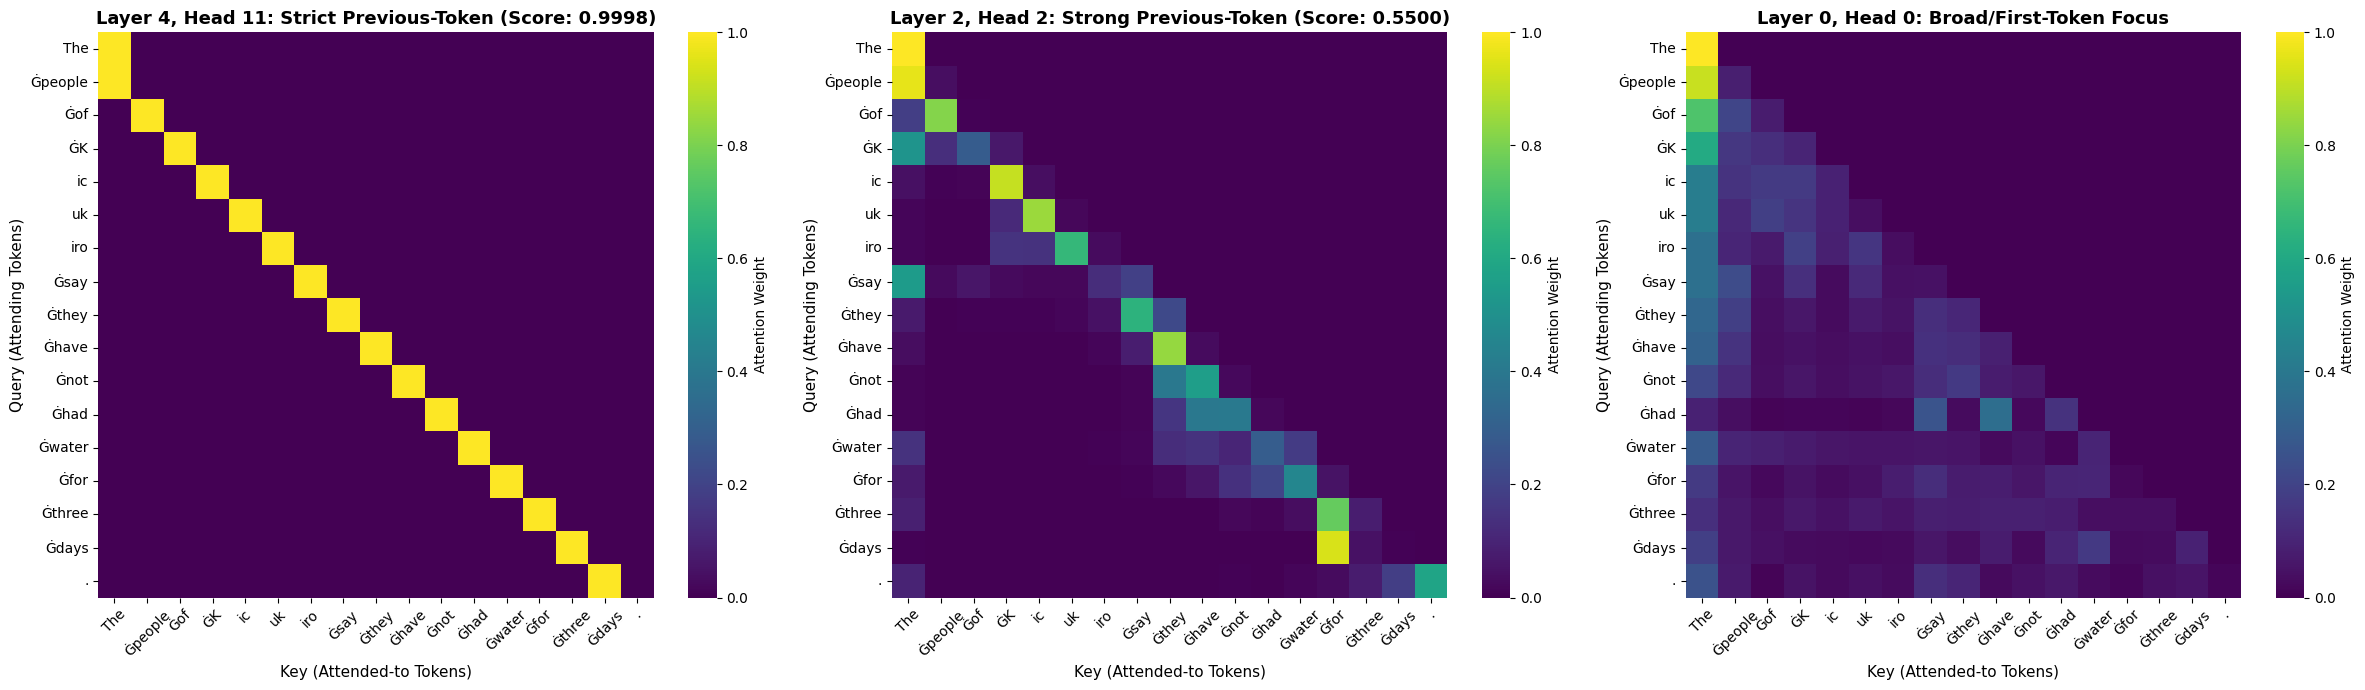

In [9]:
# Select the identified high-performing heads
# Top previous-token head found: Layer 4, Head 11
prev_layer, prev_head = 4, 11

# Second top or interesting structured head: Layer 2, Head 2
second_layer, second_head = 2, 2

# Broad/contextual head for contrast: Layer 0, Head 0
contrast_layer, contrast_head = 0, 0

heads_to_plot = [
    (prev_layer, prev_head, f"Layer {prev_layer}, Head {prev_head}: Strict Previous-Token (Score: 0.9998)"),
    (second_layer, second_head, f"Layer {second_layer}, Head {second_head}: Strong Previous-Token (Score: 0.5500)"),
    (contrast_layer, contrast_head, f"Layer {contrast_layer}, Head {contrast_head}: Broad/First-Token Focus")
]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for i, (layer, head, title) in enumerate(heads_to_plot):
    attn_matrix = attentions[layer][0, head].cpu().numpy()

    # Plotting heatmap
    sns.heatmap(
        attn_matrix,
        xticklabels=input_tokens,
        yticklabels=input_tokens,
        annot=False,
        cmap="viridis",
        ax=axes[i],
        cbar_kws={'label': 'Attention Weight'}
    )
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Key (Attended-to Tokens)", fontsize=11)
    axes[i].set_ylabel("Query (Attending Tokens)", fontsize=11)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()